In [101]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

In [102]:
# 폰트 지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

# 숫자가 지수표현식으로 나올 떄 지정
pd.options.display.float_format = '{:.2f}'.format

In [103]:
# 데이터 로드
df = pd.read_csv('dataset/HR_comma_sep.csv')

In [104]:
# 데이터 확인
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Departments,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [105]:
# left 열이 정수형인지 확인하고 필요시 변환
if df['left'].dtype != 'int64':
    df['left'] = df['left'].astype(int)

In [106]:
# 범주형 변수 확인 및 전처리
# 'Department' 끝에 공백 제거
df.rename(columns={'Departments ': 'Departments'}, inplace=True)

In [107]:
# 원-핫 인코딩 (범주형 변수 처리)
# 첫 번째 범주를 삭제하여 다중공전성을 방지
df = pd.get_dummies(df, columns=['Departments', 'salary'], drop_first=True) 

In [108]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Departments_RandD,Departments_accounting,Departments_hr,Departments_management,Departments_marketing,Departments_product_mng,Departments_sales,Departments_support,Departments_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False


In [109]:
# 독립 변수(X)와 종속 변수(y) 설정
X = df.drop('left', axis=1)
y = df['left']

In [110]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [111]:
# 데이터 스케일링
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [112]:
# 모델 학습 -랜덤 포레스트
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [113]:
# 예측
y_pred = model.predict(X_test_scaled)

In [114]:
# 평가
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Accuracy: 0.99
Confusion Matrix:
[[2286    8]
 [  27  679]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2294
           1       0.99      0.96      0.97       706

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000



In [115]:
# Feature Importance (중요 변수 확인)
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

In [116]:
print("feature_importances :")
print(feature_importances)

feature_importances :
                    Feature  Importance
0        satisfaction_level        0.33
2            number_project        0.19
4        time_spend_company        0.18
3      average_montly_hours        0.14
1           last_evaluation        0.12
5             Work_accident        0.01
16               salary_low        0.01
15    Departments_technical        0.00
17            salary_medium        0.00
13        Departments_sales        0.00
14      Departments_support        0.00
7         Departments_RandD        0.00
8    Departments_accounting        0.00
6     promotion_last_5years        0.00
9            Departments_hr        0.00
10   Departments_management        0.00
11    Departments_marketing        0.00
12  Departments_product_mng        0.00


In [117]:
# ROC 커브 시각화
from sklearn.metrics import roc_curve, auc
# 1. 모델의 예측 확률 가져오기 (양성 클래스, 즉 'Left'가 1일 확률)
# predict_proba 메서드는 각 클래스에 대한 확률을 반환하며, 두 번째 열 (인덱스 1)이 양성클래스(1)의 확률임
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [118]:
# 2. ROC 커브 계산
# fpr : False Positive Rate 거짓 양성률
# tpr : True Positive Rate 참 양성률
# thresholds : 임계값
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

In [119]:
# 3. AUC 계산
# AUC는 ROC 곡선 아래 면적으로, 1에 가까울수록 모델의 성능이 좋다고 평가
roc_auc = auc(fpr, tpr)

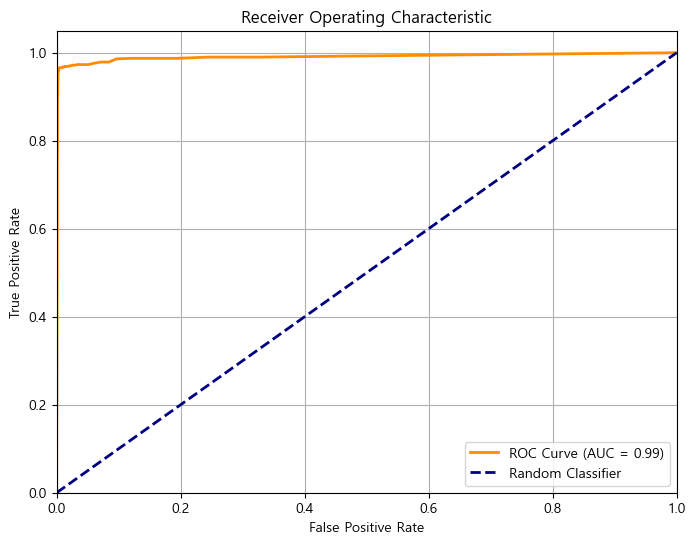

In [120]:
# 4. ROC 커브 시각화
plt.figure(figsize=(8, 6)) # 그래프 크기 설정
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})') # ROC 곡선 그리기
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier') # 랜덤 모델 비교를 위한 대각선 그리기
plt.xlim([0.0, 1.0]) # x축 범위 설정
plt.ylim([0.0, 1.05]) # y축 범위 설정
plt.xlabel('False Positive Rate') # x축 레이블 설정
plt.ylabel('True Positive Rate') # y축 레이블 설정
plt.title('Receiver Operating Characteristic') # 그래프 제목 설정
plt.legend(loc='lower right') # 범례 위치 설정
plt.grid(True) # 그리em 표시
plt.show()

In [121]:
## 컬럼명,설명  ##
# season,계절 (1: 봄, 2: 여름, 3: 가을, 4: 겨울). 범주형 데이터.
# holiday,공휴일 여부 (0: 공휴일 아님, 1: 공휴일). 이진(binary) 데이터.
# workingday,근무일 여부 (0: 근무일 아님 (주말 또는 공휴일), 1: 근무일). 이진(binary) 데이터.
# weather,날씨 상태 (1: 맑음, 약간 흐림; 2: 안개, 흐림; 3: 약한 눈/비, 천둥번개; 4: 폭우/폭설, 안개). 범주형 데이터.
# temp,정규화된 온도 (섭씨). 0과 1 사이로 스케일링된 값. 실제 온도를 얻으려면 이 값에 스케일링 인자를 곱해야 할 수 있음.
# atemp,정규화된 체감 온도 (섭씨). 0과 1 사이로 스케일링된 값. 체감 온도는 바람, 습도 등을 고려한 온도.
# humidity,정규화된 습도. 0과 1 사이로 스케일링된 값.
# windspeed,정규화된 풍속. 0과 1 사이로 스케일링된 값.
# casual,비등록 사용자(회원이 아닌 사용자)의 자전거 대여 건수. 숫자형 데이터. 주로 예측의 대상이 될 수 있음.
# registered,등록 사용자(회원)의 자전거 대여 건수. 숫자형 데이터. 주로 예측의 대상이 될 수 있음.
# count,총 자전거 대여 건수 (casual + registered). 숫자형 데이터. 이 데이터셋에서 주요 예측 목표 변수(target variable).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

# 1. 데이터 불러오기
df = pd.read_csv('dataset/bike.csv')
print('데이터 크기 :', df.shape)

데이터 크기 : (10886, 12)


In [122]:
# 2.간단한 전처리
df['datetime'] = pd.to_datetime(df['datetime'])
df['year'] = df['datetime'].dt.year
df['month'] = df['datetime'].dt.month
df['day'] = df['datetime'].dt.day
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.weekday

# 불필요한 컬럼 제거
df = df.drop(['datetime', 'casual','registered'], axis=1)

# 로그 변환 (count가 편향되어 있으므로, 예로 특정시간대에는 많고, 새벽등 다른 시간대에는 적은 경우 정규분포로 변환하여 모델학습 안정화)
df['count'] = np.log1p(df['count'])

In [123]:
# 3. X, y 분리
X = df.drop('count', axis=1)
y = df['count']

In [124]:
# 4. 학습 / 검증 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [125]:
# 5. 표준화 (XGBoost에는 꼭 필요는 없지만 예시로 포함)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [126]:
# 6. 하이퍼 파라미터 튜닝 : GridSearchCV
# 제곱오차로 MSE를 뜻함
xgb = XGBRegressor(random_state=42, objective='reg:squarederror')

param_grid = {
    'n_estimators' : [100, 200], 
    'learning_rate' : [0.1, 0.05],
    'max_depth' : [3, 4, 5],
    'subsample' : [0.8, 1.0], # 각 트리 학습에 사용되는 데이터 샘플 비율, 과적합 방지
    'colsample_bytree' : [0.8, 1.0], # 각 트리에서 사용되는 피처의 비율, 과적합방지
    'alpha' : [0, 0.1, 1], # L1 정규화 (0 : L1정규화 적용안함, 0.1~1 : 약한 정규화, 1~10 : 중간 정규화, 10~100 : 강한 정규화)
    'lambda' : [0, 0.1, 1], # L2 정규화 (0 : L2정규화 적용안함, 0.1~1 : 약한 정규화, 1~10 : 중간 정규화, 10~100 : 강한 정규화)
}

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv = 3,
    verbose=1,
    n_jobs=-1 # n_jobs= 1 : 병렬처리 없이 단일 CPU코어로 순차적 합습, n_jobs= n : n개의 CPU코어로 사용, : 모든 CPU 코어 사용)
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters :", grid.best_params_)


Fitting 3 folds for each of 432 candidates, totalling 1296 fits
Best Parameters : {'alpha': 1, 'colsample_bytree': 0.8, 'lambda': 1, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}


In [127]:
# 7. 최적 모델로 예측
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)

In [129]:
# 역변환 (log1p => 원래 값)
y_test_exp = np.expm1(y_test)
y_pred_exp = np.expm1(y_pred)

In [130]:
# 8. 평가
rmse = np.sqrt(mean_squared_error(y_test_exp, y_pred_exp))
r2 = r2_score(y_test_exp, y_pred_exp)

print(f"RMSE : {rmse:.2f}")
print(f'R2 score : {r2:.2f}')

RMSE : 39.47
R2 score : 0.95


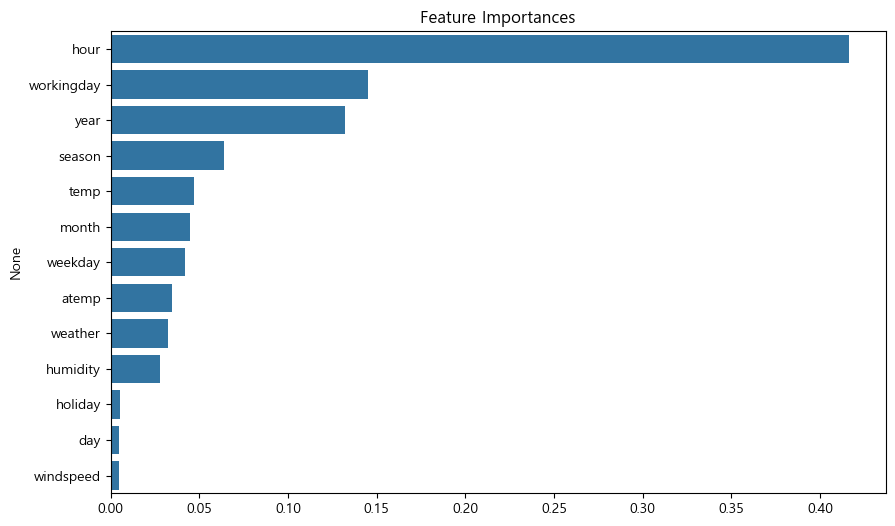

In [131]:
# 9. 피처 중요도 시각화
importances = best_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1] # argsort : 오름차순으로 정렬했을 떄의 인덱스를 반환, [::-1] : 중요도 내림차순 정렬
sorted_features = X.columns[sorted_idx]
sorted_importances = importances[sorted_idx]

plt.figure(figsize=(10, 6))
sns.barplot(
    x=sorted_importances,
    y=sorted_features,
)
plt.title('Feature Importances')
plt.show()

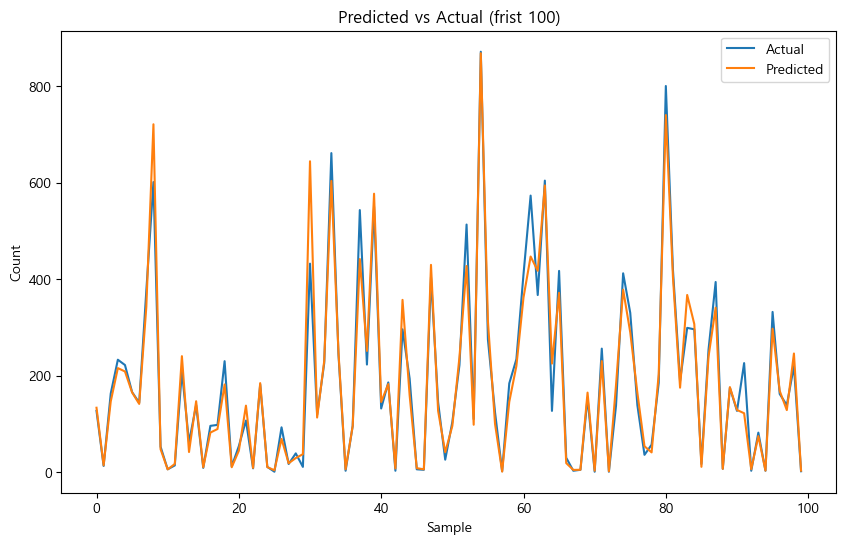

In [132]:
# 10. 예측 vs 실제 시각화
plt.figure(figsize=(10, 6))
plt.plot(y_test_exp.values[:100], label='Actual') # 테스터 데이터의 첫 100개 샘플만 시각화
plt.plot(y_pred_exp[:100], label='Predicted') # 예측 데이터의 첫 100개 샘플만 시각화
plt.legend()
plt.title("Predicted vs Actual (frist 100)")
plt.xlabel('Sample')
plt.ylabel('Count')
plt.show()